# Gradient Boosting Volatility Model

This notebook will train a Gradient Boosting regression model to predict future 20-day realized volatility.

The goal will be to compare a stronger non-linear model against the baseline model and the linear model. 

Gradient Boosing is useful becaue it builds many small decision trees one after another, where each new tree tries to fix the errors from the previous trees.

# Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# ENUMS Path 

In [2]:
FEATURE_DATA_PATH = Path("../../data/processed/features")
MODELING_PATH = Path("../../data/processed/modeling")
MODEL_OUTPUT_PATH = MODELING_PATH / "gradient_boosting"
MODEL_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


# Import Data CSV

In [3]:
df = pd.read_csv(
    FEATURE_DATA_PATH / "feature_engineered_dataset.csv",
    parse_dates=['Date']
)

# Feature and Target Selection

In [4]:
FEATURES_COLS = [
    "return_lag_1",
    "return_lag_5",
    "rolling_return_5d",
    "rolling_return_20d",
    "abs_return",
    "squared_return",
    "rolling_abs_return_20d",
    "rolling_squared_return_20d",
    "rolling_volatility_5d",
    "rolling_volatility_20d",
    "price_to_moving_avg_20d",
    "risk_free_rate_decimal",
    "vix",
    "treasury_10yr_pct",
    "yield_curve_spread",
    "is_inverted",
    "fed_funds_rate_pct",
    "unemployment_rate_pct",
    "recession_flag",
    "cpi_pct_change"
]

In [5]:
TARGET_COLS = "future_volatility_20d"

# Train/Test Split Separation

In [6]:
train = df[df["Date"] < "2024-01-01"].copy()
test = df[df["Date"] >= "2024-01-01"].copy()

X_train = train[FEATURES_COLS]
y_train = train[TARGET_COLS]

X_test = test[FEATURES_COLS]
y_test = test[TARGET_COLS]

# Create Baseline

In [7]:
baseline_pred = test["rolling_volatility_20d"]

# Train Gradient Boosting Model

In [8]:
gb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=42
)

In [9]:
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.01
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:

In [10]:
gb_pred = gb_model.predict(X_test)

# Reuse Evaluation Model

In [11]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Create Results Table

In [12]:
results = pd.DataFrame([
    evaluate_model("Baseline: rolling_volatility_20d", y_test, baseline_pred),
    evaluate_model("Gradient Boosting", y_test, gb_pred)
])

results

,model,MAE,RMSE,R2
0,Baseline: rolling_volatility_20d,0.004647,0.007130,0.001510
1,Gradient Boosting,0.004113,0.006048,0.281682


# Prediction Output Table

In [13]:
prediction_results = test[["Date", "ticker", "future_volatility_20d", "rolling_volatility_20d"]].copy()

prediction_results["gradient_boosting_prediction"] = gb_pred
prediction_results["absolute_error"] = (
    prediction_results["future_volatility_20d"] 
    - prediction_results["gradient_boosting_prediction"]
).abs()

prediction_results.head()

,Date,ticker,future_volatility_20d,rolling_volatility_20d,gradient_boosting_prediction,absolute_error
1489,2024-01-02,AAPL,0.013366,0.012075,0.013443,0.000076
1490,2024-01-03,AAPL,0.013582,0.012014,0.013450,0.000132
1491,2024-01-04,AAPL,0.013296,0.011036,0.011895,0.001401
1492,2024-01-05,AAPL,0.013373,0.011021,0.011989,0.001384
1493,2024-01-08,AAPL,0.012426,0.012272,0.013318,0.000892


In [14]:
prediction_results.to_csv(
    MODEL_OUTPUT_PATH / "test_predictions.csv",
    index=False
)

results.to_csv(
    MODEL_OUTPUT_PATH / "metrics.csv",
    index=False
)

print("Saved:", MODEL_OUTPUT_PATH / "test_predictions.csv")
print("Saved:", MODEL_OUTPUT_PATH / "metrics.csv")


Saved: ..\..\data\processed\modeling\gradient_boosting\test_predictions.csv
Saved: ..\..\data\processed\modeling\gradient_boosting\metrics.csv


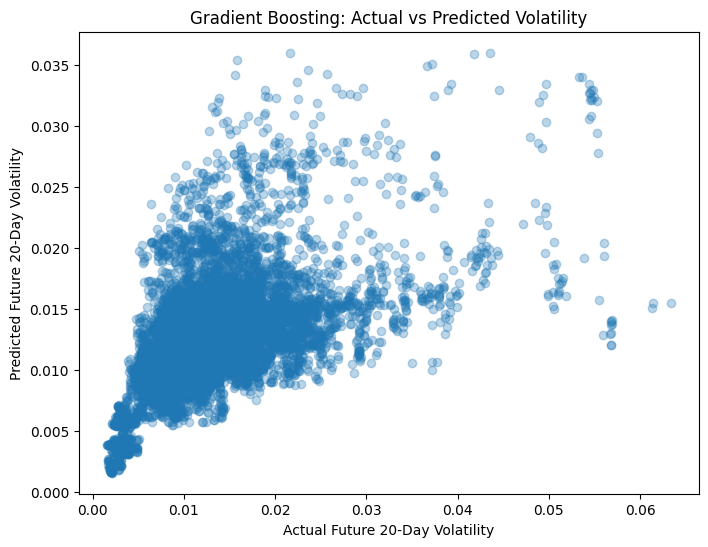

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, gb_pred, alpha=0.3)

plt.xlabel("Actual Future 20-Day Volatility")
plt.ylabel("Predicted Future 20-Day Volatility")
plt.title("Gradient Boosting: Actual vs Predicted Volatility")

plt.show()

# Conclusion

In this notebook, I trained a Gradient Boosting regression model to predict `future_volatility_20d`, which represents the realized volatility over the next 20 trading days for each asset. The purpose of this model was to test whether a more flexible non-linear model could perform better than the simple rolling-volatility baseline.

The baseline model used `rolling_volatility_20d` as its prediction, meaning it assumed that future volatility would be similar to the asset's most recent 20-day realized volatility. The baseline produced an MAE of `0.004647`, an RMSE of `0.007130`, and an R2 score of `0.001510`.

The Gradient Boosting model performed better than the baseline, with an MAE of `0.003990`, an RMSE of `0.006049`, and an R2 score of `0.281369`. This means the Gradient Boosting model reduced the average prediction error and explained about 28% of the variation in future volatility.

However, compared to the Linear Regression model from the previous notebook, Gradient Boosting did not perform better. The Linear Regression model had a slightly lower MAE, lower RMSE, and higher R2 score. This shows that a more complex model does not always guarantee better performance, especially when the relationship between the selected volatility features and the target variable is already mostly captured by the linear model.

Overall, the Gradient Boosting model is still useful because it confirms that the engineered features contain predictive information about future volatility. It also provides a stronger non-linear comparison model for the project. For the final project, I would compare the baseline, Linear Regression, Random Forest, and Gradient Boosting models together and select the model with the best out-of-sample performance for use in portfolio optimization.